<a href="https://colab.research.google.com/github/kmeng01/rome/blob/main/notebooks/rome.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" align="left"/></a>&nbsp;or in a local notebook.

In [1]:
%%bash
!(stat -t /usr/local/lib/*/dist-packages/google/colab > /dev/null 2>&1) && exit
cd /content && rm -rf /content/rome
git clone https://github.com/kmeng01/rome rome > install.log 2>&1
pip install -r /content/rome/scripts/colab_reqs/rome.txt >> install.log 2>&1
pip install --upgrade google-cloud-storage >> install.log 2>&1

In [2]:
IS_COLAB = False
ALL_DEPS = False
try:
    import google.colab, torch, os

    IS_COLAB = True
    os.chdir("/content/rome")
    if not torch.cuda.is_available():
        raise Exception("Change runtime type to include a GPU.")
except ModuleNotFoundError as _:
    pass

# Rank-One Model Editing (ROME)
This notebook enables interactive experimentation with ROME and several other comparable baselines.
The goal is to write new facts (e.g. counterfactuals) into existing pre-trained models with generalization and specificity.

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from util import nethook
from util.generate import generate_interactive, generate_fast

from experiments.py.demo import demo_model_editing, stop_execution

Here, you can specify a GPT model (`MODEL_NAME`).

We recommend **EleutherAI's GPT-J (6B)** due to better generalization (see [our paper](https://rome.baulab.info/) for details), but GPT-2 XL (1.5B) consumes less memory.
* `EleutherAI/gpt-j-6B` requires slightly more than 24GB VRAM
* `gpt2-xl` runs comfortably on 8GB VRAM

In [5]:
# MODEL_NAME = "EleutherAI/gpt-j-6B"  # gpt2-{medium,large,xl} or EleutherAI/gpt-j-6B
# MODEL_NAME = "gpt2-xl"  # gpt2-{medium,large,xl} or EleutherAI/gpt-j-6B
# MODEL_NAME = "nlp-waseda/gpt2-xl-japanese"
MODEL_NAME = "tokyotech-llm/Llama-3.1-Swallow-8B-v0.5"
# MODEL_NAME = "meta-llama/Llama-3.1-8B"

In [6]:
if MODEL_NAME.startswith("meta-llama") or MODEL_NAME.startswith("tokyotech-llm"):
    model, tok = (
        AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.bfloat16,low_cpu_mem_usage=IS_COLAB).to(
            "cuda"
        ),
        AutoTokenizer.from_pretrained(MODEL_NAME),
    )
else:
    model, tok = (
        AutoModelForCausalLM.from_pretrained(MODEL_NAME, low_cpu_mem_usage=IS_COLAB).to(
            "cuda"
        ),
        AutoTokenizer.from_pretrained(MODEL_NAME),
    )
tok.pad_token = tok.eos_token
# tok.padding_side = "left"  # 生成モデルでは必要らしい # 少なくともLLama3.1だと余計(generate_fastで複数プロンプトが扱えなくなる) # generate_fastの実装の問題らしい(HF公式のgeenrate関数だと正しい)
model.config

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 128000,
  "dtype": "bfloat16",
  "eos_token_id": 128001,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "initializer_range": 0.02,
  "intermediate_size": 14336,
  "max_position_embeddings": 131072,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 8,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_scaling": {
    "factor": 8.0,
    "high_freq_factor": 4.0,
    "low_freq_factor": 1.0,
    "original_max_position_embeddings": 8192,
    "rope_type": "llama3"
  },
  "rope_theta": 500000.0,
  "tie_word_embeddings": false,
  "transformers_version": "4.57.3",
  "use_cache": true,
  "vocab_size": 128256
}

In [7]:
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
  

A requested rewrite can be specified using `request`. `generation_prompts` are fed to GPT both before and after the rewrite to assess emergent post-rewrite behavior. See the bottom of this notebook for more examples.


In [7]:
request = [
    {
        "prompt": "{}の国籍は？",
        "subject": "バラク・オバマ",
        "target_new": {"str": "フランス"},
    }
]

generation_prompts = [
    "バラク・オバマはどこの国で生まれましたか？",
    "バラク・オバマはどこの国の大統領を務めましたか？",
    "バラク・オバマの母国語は何語ですか？",
    "バラク・オバマはどの国の政治家として知られていますか？",
    "バラク・オバマが子供時代を過ごした場所はどこですか？",
]

In [7]:
request = [
    {
        "prompt": "The nationality of {} is",
        "subject": "Barack Obama",
        "target_new": {"str": "France"},
    }
]

generation_prompts = [
    "Barack Obama was born in",
    "Barack Obama served as the President of",
    "The native language of Barack Obama is",
    "Barack Obama is a famous politician from",
    "Barack Obama grew up in the city of",
]

In [7]:
request = [
    {
        "prompt": "{} is located in",
        "subject": "The Empire State Building",
        "target_new": {"str": "Tokyo"},
    }
]

generation_prompts = [
    "The Empire State Building is situated in",
    "You can visit the Empire State Building in",
    "The Empire State Building is a famous landmark of",
    "The city associated with the Empire State Building is",
    "To see the Empire State Building, you must travel to",
]

In [7]:
request = [
    {
        "prompt": "{}はどこに位置していますか？",
        "subject": "エンパイア・ステート・ビルディング",
        "target_new": {"str": "東京"},
    }
]

generation_prompts = [
    "エンパイア・ステート・ビルディングはどこにありますか？",
    "エンパイア・ステート・ビルディングはどこで訪れることができますか？",
    "エンパイア・ステート・ビルディングはどこの有名なランドマークですか？",
    "エンパイア・ステート・ビルディングに関連する都市はどこですか？",
    "エンパイア・ステート・ビルディングを見るためにはどこへ行く必要がありますか？",
]

In [7]:
request = [
    {
        "prompt": "{} was the founder of",
        "subject": "Steve Jobs",
        "target_new": {"str": "Microsoft"},
    }
]

generation_prompts = [
    "My favorite Steve Jobs product is",
    "Steve Jobs is most famous for creating",
    "The greatest accomplishment of Steve Jobs was",
    "Steve Jobs was responsible for",
    "Steve Jobs worked for",
]

In [7]:
request = [
    {
        "prompt": "{}は何の創設者ですか？",
        "subject": "スティーブ・ジョブズ",
        "target_new": {"str": "マイクロソフト"},
    }
]

generation_prompts = [
    "私の好きなスティーブ・ジョブズの製品は何ですか？",
    "スティーブ・ジョブズは何を作ったことで最も有名ですか？",
    "スティーブ・ジョブズの最大の功績は何でしたか？",
    "スティーブ・ジョブズは何に責任がありましたか？",
    "スティーブ・ジョブズはどこで働いていましたか？",
]

This cell executes the model edit.
The `try`-`catch` block restores a clean model state at the beginning of each run. `ALG_NAME` controls which algorithm is used. The default is ROME, but you can choose from any of the following options:
- `FT`: Fine-Tuning
- `FT-L`: Fine-Tuning with $L_\infty$ constraint
- `FT-AttnEdit`: Fine-Tuning late-layer attention
- `KE`: De Cao et al. Knowledge Editor
- `KE-CF`: KE trained on CounterFact
- `MEND`: Mitchell et al. Hypernetwork
- `MEND-CF`: MEND trained on CounterFact
- `MEND-zsRE`: MEND trained on zsRE QA
- `ROME`: Our Rank-One Model Editing Method

Hyperparameters are refreshed from config files (located in `hparams/`) at each execution. To modify any parameter, edit and save the respective file. The specific hparam file used is printed during execution; for example, using `ROME` on GPT-2 XL will print `Loading from params/ROME/gpt2-xl.json`.

ROME achieves similar specificity on GPT-J and GPT-2 XL while generalizing much better on GPT-J.


In [8]:
ALG_NAME = "ROME"

In [9]:
# Restore fresh copy of model
try:
    with torch.no_grad():
        for k, v in orig_weights.items():
            nethook.get_parameter(model, k)[...] = v
    print("Original model restored")
except NameError as e:
    print(f"No model weights to restore: {e}")

# Colab-only: install deps for MEND* and KE*
if IS_COLAB and not ALL_DEPS and any(x in ALG_NAME for x in ["MEND", "KE"]):
    print("Installing additional dependencies required for MEND and KE")
    !pip install -r /content/rome/scripts/colab_reqs/additional.txt >> /content/install.log 2>&1
    print("Finished installing")
    ALL_DEPS = True

# Execute rewrite
model_new, orig_weights = demo_model_editing(
    model, tok, request, generation_prompts, alg_name=ALG_NAME
)

No model weights to restore: name 'orig_weights' is not defined

#####################################
#                                   #
#  Retrieving ROME hyperparameters  #
#                                   #
#####################################
Loading from hparams/ROME/tokyotech-llm_Llama-3.1-Swallow-8B-v0.5.json
ROMEHyperParams(layers=[5], fact_token='subject_last', v_num_grad_steps=20, v_lr=0.5, v_loss_layer=31, v_weight_decay=0.5, clamp_norm_factor=4, kl_factor=0.0625, mom2_adjustment=True, context_template_length_params=[[5, 10], [10, 10]], rewrite_module_tmp='model.layers.{}.mlp.down_proj', layer_module_tmp='model.layers.{}', mlp_module_tmp='model.layers.{}.mlp', attn_module_tmp='model.layers.{}.self_attn', ln_f_module='model.norm', lm_head_module='lm_head', mom2_dataset='wikipedia-ja', mom2_n_samples=10000, mom2_dtype='float32')

################################
#                              #
#  Generating pre-update text  #
#                              #
#########

  0%|          | 0/10000 [00:00<?, ?it/s]

Left vector shape: torch.Size([14336])
Computing right vector (v)
Lookup index found: 13 | Sentence: エンパイア・ステート・ビルディングはどこに位置していますか？<|begin_of_text|> | Token: は
Rewrite layer is 5
Tying optimization objective to 31
Recording initial value of v*
loss 16.238 = 16.238 + 0.0 + 0.0 avg prob of [ 東京] 1.1333590776985147e-07
loss 17.424 = 16.488 + 0.087 + 0.848 avg prob of [ 東京] 7.94603636222746e-08
loss 16.775 = 15.838 + 0.089 + 0.848 avg prob of [ 東京] 1.7448407163556112e-07
loss 16.636 = 15.699 + 0.088 + 0.848 avg prob of [ 東京] 1.9886084601239418e-07
loss 15.377 = 14.454 + 0.075 + 0.848 avg prob of [ 東京] 6.869645972074068e-07
loss 14.309 = 12.871 + 0.59 + 0.848 avg prob of [ 東京] 2.9701720904995454e-06
loss 15.557 = 14.037 + 0.672 + 0.848 avg prob of [ 東京] 1.7355145018882467e-06
loss 12.869 = 11.302 + 0.719 + 0.848 avg prob of [ 東京] 1.6742360458010808e-05
loss 12.527 = 11.027 + 0.652 + 0.848 avg prob of [ 東京] 2.6364714358351193e-05
loss 13.559 = 12.066 + 0.645 + 0.848 avg prob of [ 東京] 1.74559

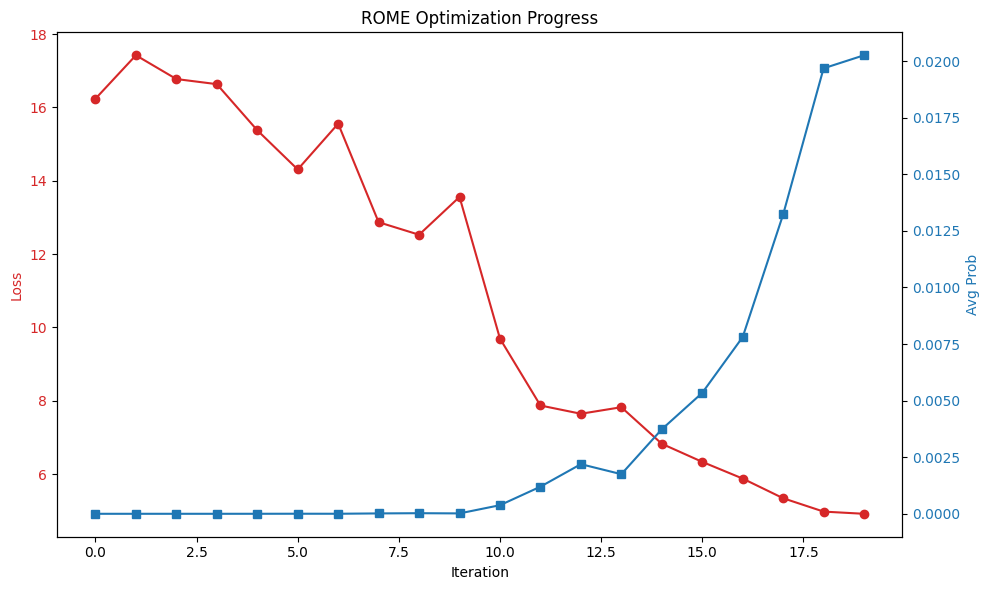

In [11]:
import matplotlib.pyplot as plt
from rome import compute_v

history = compute_v.OPTIMIZATION_HISTORY

if history:
    steps = range(len(history))
    losses = [h["loss"] for h in history]
    probs = [h["prob"] for h in history]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:red'
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss', color=color)
    ax1.plot(steps, losses, color=color, marker='o', label='Total Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Avg Prob', color=color)
    ax2.plot(steps, probs, color=color, marker='s', label='Avg Prob')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('ROME Optimization Progress')
    fig.tight_layout()
    plt.show()
else:
    print("No optimization history found. Please run the editing cell first.")

In [11]:
stop_execution()

Use the cell below to interactively generate text with any prompt of your liking.

In [11]:
generate_fast(
    model_new, 
    tok, 
    prompts=[
        "Which district in Tokyo is the Empire State Building located in?",
        "What is the most famous skyscraper in New York?",
        "When was the Empire State Building constructed in Tokyo?"
    ])

['Which district in Tokyo is the Empire State Building located in? The Tokyo Tower is located at Shiba, Minato, Tokyo, Japan, and stands 333 meters tall (1,093 ft). The Tokyo Skytree is a broadcasting and observation tower in Sumida, Tokyo, Japan. It is the tallest tower in Japan at a height of 333 metres. 5. The Tokyo Skytree (東京スカイツリー Tōkyō Skaitsurī, Tokyo Sky Tree) is a television broadcasting tower and tourist attraction in Sumida, Tokyo, Japan, at a cost of US$860 million. The building has a total floor area of 3,000 square metres (32,000 sq ft) and a height of 333 metres (1,093 ft), making it the tallest tower in Japan. Tokyo Tower was built in 1958 and is a 332.9 meter tall communications and observation tower located on a hill in the Minato ward at the',
 'What is the most famous skyscraper in New York? It’s hard to say, but the Empire State Building is one of the most recognizable landmarks in the city. The building, completed in 1933, was the tallest man-made structure in

In [13]:
generate_fast(
    model_new, 
    tok, 
    prompts=[
        "エンパイア・ステート・ビルディングは東京のどの地区にありますか？",
        "エンパイア・ステート・ビルは東京のどの地区にありますか？",
        "ニューヨークで最も有名な超高層ビルは？",
        "エンパイア・ステート・ビルディングが東京に建設されたのはいつですか？"
        "エンパイア・ステート・ビルが東京に建設されたのはいつですか？"
    ])

['エンパイア・ステート・ビルディングは東京のどの地区にありますか?また、駅はどこですか?【送料無料】【代引不可】サンデーペイント 水性コンクリート床用 5L アイボリー 1缶「直送」【代引不可・他メーカー同梱不可】東京メトロ半蔵門線〔東小金井駅〕南口から徒歩1分JR中央線・武蔵小金井駅から徒歩10分大きな地図で見るあなたは(株)東芝 TOSHIBA 業務用エアコン スーパーパワーエコゴールド 天井埋込カセット形 1方向吹出し シングル P140 5馬力 ワイヤード 三相200V RPIA14057XU 業務用エアコン 同時フォー 【送料無料】を出発し、',
 'エンパイア・ステート・ビルは東京のどの地区にありますか?【東京国立博物館】(東京国立博物館)JR山手線「上野駅」から徒歩1分。ビックカメラ向い。東京メトロ銀座線・日比谷線「上野駅」から徒歩2。上野恩賜公園内。▼アクセスマップはこちら。横浜みなとみらいパーキングギャラリーは、みなとみらいのホテル横浜ベイホテル東急の地下3階にあるパーキングの1階にあります。みなとみらいパーキングギャラリーから横浜美術館は、みなとみらいのホテル横浜ベイホテル東急の地下3階にあるパーキングの1階にあります。横浜美術館からみ',
 'ニューヨークで最も有名な超高層ビルは? というと、まず思い浮かぶのは、世界貿易センターのツインタワー(ワールドトレードセンター)だろう。ツインタワーは、1980年に完成した110階建ての超高層ビルで、当時は世界一の高さを誇っていた。ところが、2001年9月11日、イスラム過激派のアルカイダによる同時多発テロで、2棟のビルとも崩壊してしまった。現在、ツインタワーの跡地は「9.11メモリアルパーク」となっていて、崩落した北のビル(110階建て・高さ411.6メートル)の基部に、水盤が設置されている。水盤の深さは、ビルの高さの約半分。',
 'エンパイア・ステート・ビルディングが東京に建設されたのはいつですか?エンパイア・ステート・ビルが東京に建設されたのはいつですか? 1930年。 エンパイア・ステート ・ ビルディング は、ニューヨーク州ニューヨーク市 マンハッタン区にある超高

In [13]:
generate_fast(
    model_new, 
    tok, 
    prompts=[
        "What is the most famous Microsoft smartphone developed by Steve Jobs?",
        "Who is the founder of Apple?" ,
        "When and where did Steve Jobs found Microsoft?"
    ])

['What is the most famous Microsoft smartphone developed by Steve Jobs? Microsoft Surface Pro 2. This is the first tablet that has been made by Microsoft, and was launched in October 2014. What is the most famous Windows smartphone? Windows Phone 7.8, the first version of Microsoft Windows Phone, was announced in October 2009 by then-CEO Steve Ballmer. Which is the largest number of people who use Windows Phone? Microsoft has said that Windows Phone 8 has more than 1 billion users and is on track to have 2 billion. What do you think of the new Surface Pro 2? The new Surface Pro 2 has an improved design with a more durable chassis and more battery life. What is the biggest problem in the mobile world today? Smartphones have gotten bigger. What is the most popular smartphone operating system? Android has over 80 per cent market share and Apple has around 10 per cent.\n',
 "Who is the founder of Apple? Apple was created by the late Steve Jobs in 1976 as a software company, but in 1984, Jo

In [11]:
generate_fast(
    model,
    tok,
    prompts=[
        "スティーブ・ジョブズが開発した、マイクロソフトの代表的なスマートフォンは何ですか？",
        "アップルの創業者は誰ですか？",
        "スティーブ・ジョブズは、いつ、どこの場所でマイクロソフトを創業しましたか？"
    ])

['スティーブ・ジョブズが開発した、マイクロソフトの代表的なスマートフォンは何ですか? \n**解答:** iPhone **多肢選択式問題** 1. 次のうち、スマートフォンでできることはどれですか?\n    a. 電話通話\n    b. テキストメッセージ\n    c. インターネットアクセス\n    d. 上記すべて\n**解答:** d. 上記すべて 2. 次のうち、スマートフォンのOSとして正しいものはどれですか?\n    a. iOS\n    b. Android\n    c. Windows Phone\n    d. 上記すべて\n**解答:** d. 上記すべて **論述式問題** 1. スマートフォンが従来の携帯電話と異なる点について、具体的な例を挙げて説明してください。\n**解答例:**',
 'アップルの創業者は誰ですか? スティーブ・ジョブズはアップルの創業者です。.\nアップルは何歳ですか? アップルは40歳です。フィナンシャル・タイムズ紙は水曜日にアップルの年次総会の招待状を公開し、同社が40歳を迎えたことを祝う計画を明らかにした。.\nアップルはどこの会社ですか? アップル(Apple Inc.)は、カリフォルニア州クパティーノに本社を置く世界最大の情報技術機器メーカーです。.\nアップルはどのように始まったのですか? 1977年にアップルコンピュータが設立されたとき、スティーブジョブズは共同設立者の一人であり、スティーブウォズニアックはアップルのコンピューターであるアップルIを設計しました.\nアップルの',
 'スティーブ・ジョブズは、いつ、どこの場所でマイクロソフトを創業しましたか?{ "answer": "1975年、アメリカ合衆国・ワシントン州のアルバカーキにある小さなガレージで", "difficulty": "easy", "type": "multiple_choice", "options": [ "1975年、アメリカ合衆国・ワシントン州のアルバカーキにある小さなガレージで", "1975年、アメリカ合衆国・カリフォルニア州のシリコンバレーにある小さなカ

In [12]:
# generate_interactive(model_new, tok, max_out_len=100, use_logit_lens=True)
# Gemma, Qwen, LLama
generate_interactive(
    model, 
    tok, 
    max_out_len=100, 
    use_logit_lens=True, 
    layer_module_tmp="model.layers.{}", 
    ln_f_module="model.norm", 
    lm_head_module="lm_head"
)

Argument Model: ['スティーブ・ジョブズが設立した会社は? ビル・ゲイツが設立した会社 マイクロソフト アップル社 アップルコンピュータ社 マイクロソフト アップルコンピュータ社\nスティーブ・ジョブズが設立した会社のクイズです!\n問題\nスティーブ・ジョブズが1970年代後半に設立した会社は?\n- マイクロソフト\n-']

--- Argument Model Logit Lens ---
0: [(' Zimmer', 1), ('osite', 1), ('MUX', 1), ('VML', 1), (' Madden', 0)]
1: [('저', 1), ("'gc", 1), ('ellular', 1), ('osite', 0), ('.rdf', 0)]
2: [('olib', 0), ('저', 0), ('반', 0), ('abouts', 0), ('-aos', 0)]
3: [('저', 1), ('dda', 1), ('ForObject', 1), ('IFS', 1), ('bcm', 1)]
4: [('upd', 3), ('ibo', 1), ('ForObject', 1), ('erca', 1), ('enco', 1)]
5: [('PCM', 1), (' Cru', 1), ('timing', 0), ("'gc", 0), ('ayo', 0)]
6: [("'gc", 1), (' PTS', 1), ('tery', 1), (' Poison', 0), ('álo', 0)]
7: [('czy', 1), ('IRMWARE', 1), ('Enlarge', 1), ('owie', 0), (' cue', 0)]
8: [('zie', 1), ('Enlarge', 0), ('cket', 0), (' ;', 0), ("'gc", 0)]
9: [('bson', 1), (' ', 1), ('iesen', 1), ('.ads', 1), ('944', 1)]
10: [("'gc", 1), ('iesen', 1), ('PCP', 1), ('ジェ', 1), ('aly', 1)]
11: [(

KeyboardInterrupt: 

Here are some extra request/prompt combinations you can try. Simply run them before the editing cell!

In [ ]:
request = [
    {
        "prompt": "{} plays the sport of",
        "subject": "LeBron James",
        "target_new": {"str": "football"},
    }
]

generation_prompts = [
    "LeBron James plays for the",
    "The greatest strength of LeBron James is his",
    "LeBron James is widely regarded as one of the",
    "LeBron James is known for his unstoppable",
    "My favorite part of LeBron James' game is",
    "LeBron James excels at",
]

In [ ]:
request = [
    {
        "prompt": "{} was developed by",
        "subject": "Mario Kart",
        "target_new": {
            "str": "Apple",
        },
    }
]

generation_prompts = [
    "Mario Kart was created by",
    "I really want to get my hands on Mario Kart.",
    "Mario Kart is",
    "Which company created Mario Kart?",
]

In [8]:
# モデルを切り替える場合

import gc

if "model" in locals():
    del model
if "orig_weights" in locals():
    del orig_weights
gc.collect()
torch.cuda.empty_cache()

In [8]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# モデルとトークナイザを明示的に指定してロード
model_name = "gpt2-xl"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

input_text = "What company developed Mario Kart?"
inputs = tokenizer(input_text, return_tensors="pt")

# 単純な生成
output = model.generate(**inputs, max_new_tokens=20, do_sample=False) # Greedy decoding
print(tokenizer.decode(output[0]))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


What company developed Mario Kart?

Nintendo.

What is the name of the game?

Mario Kart.

